# Unlocking Growth at Olist — An End-to-End Data Analytics Case Study
--- 
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)  
**Tool:** Python (Pandas, Matplotlib, Seaborn, Scikit-learn)

## Business Context
Olist is a Brazilian e-commerce marketplace connecting thousands of sellers 
to customers nationwide. This analysis investigates 100,000 real orders 
(2016–2018) to uncover revenue drivers, customer behavior patterns, and 
actionable growth opportunities.

## Business Questions
1. Is Olist's growth sustainable, or is it a spike?
2. Which product categories are secretly hurting the business?
3. Is late delivery killing customer satisfaction — and by how much?
4. Which states are high opportunity vs high risk?
5. Who are our customers really? (RFM + Clustering)
6. What are customers saying? (NLP on reviews)

In [1]:
# ── IMPORTS 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling — makes all charts look professional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'

In [2]:
# Load olist datasets

In [3]:
path = "../data/"

In [4]:
orders = pd.read_csv(path + "olist_orders_dataset.csv")
orders.shape

(99441, 8)

In [5]:
order_items  = pd.read_csv(path + "olist_order_items_dataset.csv")
payments     = pd.read_csv(path + "olist_order_payments_dataset.csv")
reviews      = pd.read_csv(path + "olist_order_reviews_dataset.csv")
customers    = pd.read_csv(path + "olist_customers_dataset.csv")
sellers      = pd.read_csv(path + "olist_sellers_dataset.csv")
products     = pd.read_csv(path + "olist_products_dataset.csv")
geo          = pd.read_csv(path + "olist_geolocation_dataset.csv")
category     = pd.read_csv(path + "product_category_name_translation.csv")

In [6]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [8]:
print(orders.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [9]:
orders.order_status.value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [10]:
# Keep only delivered orders — revenue recognized on delivery only
delivered_orders=orders[orders['order_status'] == "delivered" ]
print(delivered_orders.shape)

(96478, 8)


In [11]:
# Convert to datetime — needed for time-based trend analysis

In [12]:
delivered_orders['order_purchase_timestamp'] = pd.to_datetime(delivered_orders['order_purchase_timestamp'])

In [13]:
delivered_orders['order_delivered_customer_date'] = pd.to_datetime(delivered_orders['order_delivered_customer_date'])

In [14]:
delivered_orders['order_estimated_delivery_date'] = pd.to_datetime(delivered_orders['order_estimated_delivery_date'])

In [15]:
delivered_orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [16]:
delivered_orders.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

In [17]:
print(f"Total delivered orders: {delivered_orders.shape[0]:,}")

Total delivered orders: 96,478


In [18]:
print(f"date range : {delivered_orders['order_purchase_timestamp'].min().date()} to {delivered_orders['order_purchase_timestamp'].max().date()} ")

date range : 2016-09-15 to 2018-08-29 


In [19]:
print(order_items.columns.tolist())

['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


In [20]:
# Aggregate order items before joining
items_agg = order_items.groupby('order_id').agg(
    order_value=('price', 'sum'),
    freight_value=('freight_value', 'sum'),
    item_count=('order_item_id', 'count'),
    product_id=('product_id', 'first')
).reset_index()

In [21]:
df = delivered_orders.merge(items_agg, on='order_id', how='left')
df.shape

(96478, 12)

In [22]:
df = df.merge(customers,on="customer_id",how = "left")
df.shape

(96478, 16)

In [23]:
# Aggregate payments — one order can have multiple payment methods
payments_agg = payments.groupby('order_id').agg(
    payment_value=('payment_value', 'sum'),
    payment_type=('payment_type', 'first'),
    payment_installments=('payment_installments', 'max')
).reset_index()

In [24]:
df = df.merge(payments_agg, on='order_id', how='left')
print(df.shape)

(96478, 19)


In [25]:
# Built master dataframe — joining all tables on order_id
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_value,freight_value,item_count,product_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_type,payment_installments
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,1,87285b34884572647811a353c7ac498a,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,credit_card,1.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,1,595fac2a385ac33a80bd5114aec74eb8,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,boleto,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,1,aa4383b373c6aca5d8797843e5594415,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,credit_card,3.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,1,d0b61bfb1de832b15ba9d266ca96e5b0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,credit_card,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,1,65266b2da20d04dbe00c5c2d3bb7859e,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,credit_card,1.0


In [26]:
# Aggregate reviews first — one review per order
reviews_agg = reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean'),
    review_comment=('review_comment_message', 'first')
).reset_index()

In [27]:
df = df.merge(reviews_agg, on='order_id', how='left')
print(df.shape)

(96478, 21)


In [28]:
products_merged = products.merge(category,on="product_category_name",how="left")

In [29]:
df = df.merge(products_merged[['product_id','product_category_name_english']],on="product_id",how="left")

In [30]:
df.shape

(96478, 22)

In [31]:
df.columns.to_list()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'order_value',
 'freight_value',
 'item_count',
 'product_id',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'payment_value',
 'payment_type',
 'payment_installments',
 'review_score',
 'review_comment',
 'product_category_name_english']

In [32]:
print(df.isnull().sum()[df.isnull().sum() > 0])

order_approved_at                   14
order_delivered_carrier_date         2
order_delivered_customer_date        8
payment_value                        1
payment_type                         1
payment_installments                 1
review_score                       646
review_comment                   57516
product_category_name_english     1378
dtype: int64


In [33]:
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M') 

In [34]:
df['order_month'].value_counts().sort_index().head(10)

order_month
2016-09       1
2016-10     265
2016-12       1
2017-01     750
2017-02    1653
2017-03    2546
2017-04    2303
2017-05    3546
2017-06    3135
2017-07    3872
Freq: M, Name: count, dtype: int64

In [35]:
# North Star Metric — monthly revenue, order volume and AOV

monthly_revenue = df.groupby('order_month').agg(
    revenue = ('payment_value','sum'),
    orders = ('order_id','count'),
).reset_index()

In [36]:
monthly_revenue

,order_month,revenue,orders
0,2016-09,0.00,1
1,2016-10,46566.71,265
2,2016-12,19.62,1
3,2017-01,127545.67,750
4,2017-02,271298.65,1653
5,2017-03,414369.39,2546
6,2017-04,390952.18,2303
7,2017-05,567066.73,3546
8,2017-06,490225.60,3135
9,2017-07,566403.93,3872


In [37]:
# Average order value (AOV)
monthly_revenue['aov']= monthly_revenue['revenue']/monthly_revenue['orders']

In [38]:
monthly_revenue

,order_month,revenue,orders,aov
0,2016-09,0.00,1,0.000000
1,2016-10,46566.71,265,175.723434
2,2016-12,19.62,1,19.620000
3,2017-01,127545.67,750,170.060893
4,2017-02,271298.65,1653,164.125015
5,2017-03,414369.39,2546,162.753099
6,2017-04,390952.18,2303,169.757785
7,2017-05,567066.73,3546,159.917296
8,2017-06,490225.60,3135,156.371802
9,2017-07,566403.93,3872,146.282007


In [39]:
# remove incomplete months
monthly_revenue = monthly_revenue.iloc[1:-1]

In [40]:
monthly_revenue

,order_month,revenue,orders,aov
1,2016-10,46566.71,265,175.723434
2,2016-12,19.62,1,19.620000
3,2017-01,127545.67,750,170.060893
4,2017-02,271298.65,1653,164.125015
5,2017-03,414369.39,2546,162.753099
6,2017-04,390952.18,2303,169.757785
7,2017-05,567066.73,3546,159.917296
8,2017-06,490225.60,3135,156.371802
9,2017-07,566403.93,3872,146.282007
10,2017-08,646000.61,4193,154.066446


In [41]:
len(monthly_revenue)

21

In [42]:
print(f"Total Revenue : R$ {monthly_revenue['revenue'].sum():,.2f}")

Total Revenue : R$ 14,437,047.49


## Monthly revenue trend

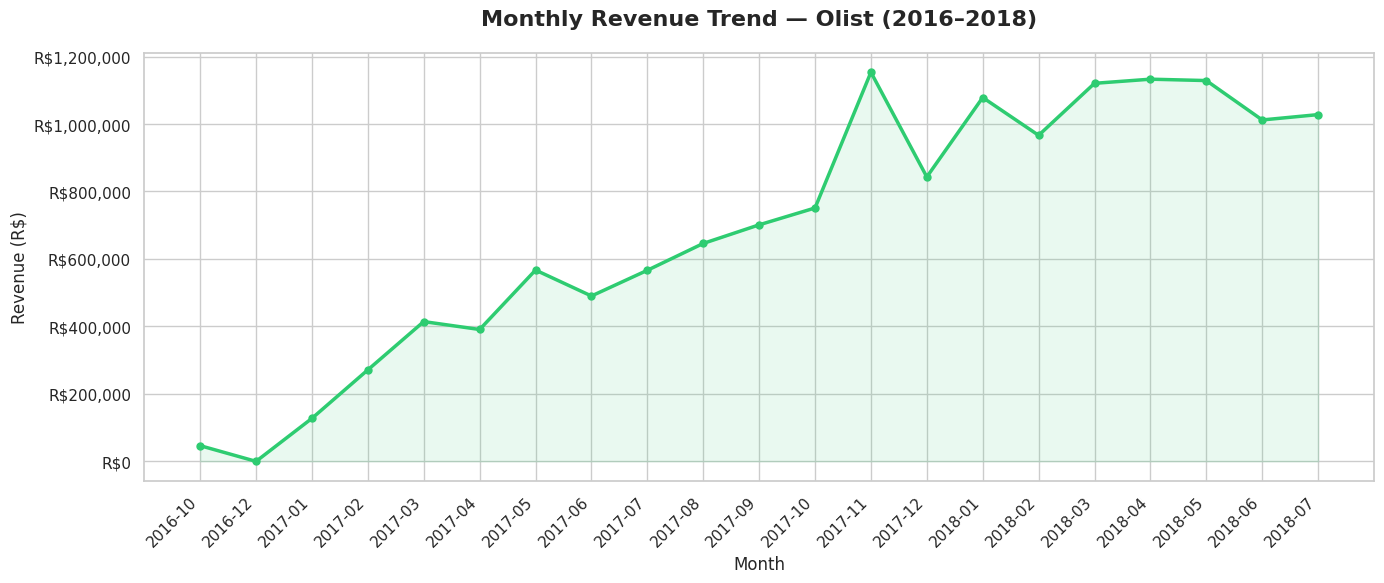

In [43]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_revenue['order_month'].astype(str), 
        monthly_revenue['revenue'], 
        color='#2ecc71', linewidth=2.5, marker='o', markersize=5)

ax.fill_between(monthly_revenue['order_month'].astype(str), 
                monthly_revenue['revenue'], 
                alpha=0.1, color='#2ecc71')

ax.set_title('Monthly Revenue Trend — Olist (2016–2018)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Revenue (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

plt.tight_layout()
plt.savefig('../charts/chart1_monthly_revenue.png', dpi=150)
plt.show()

## Monthly Order Volume

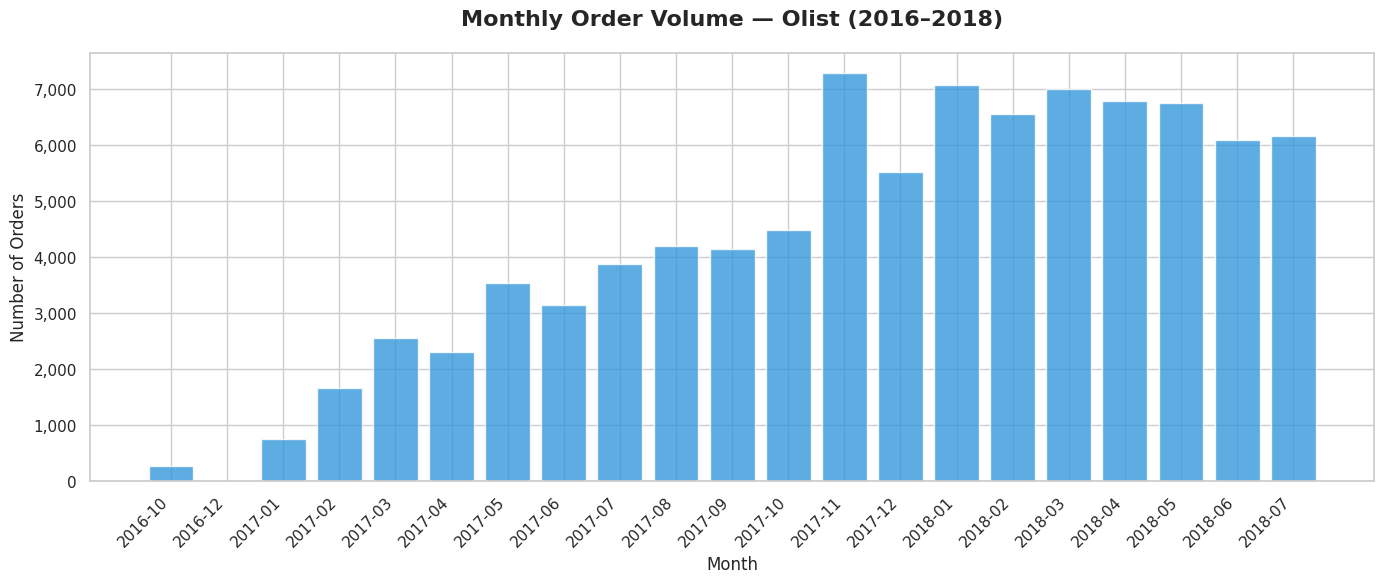

In [44]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(monthly_revenue['order_month'].astype(str),
       monthly_revenue['orders'],
       color='#3498db', alpha=0.8)

ax.set_title('Monthly Order Volume — Olist (2016–2018)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('../charts/chart2_order_volume.png', dpi=150)
plt.show()

## AOV Trend

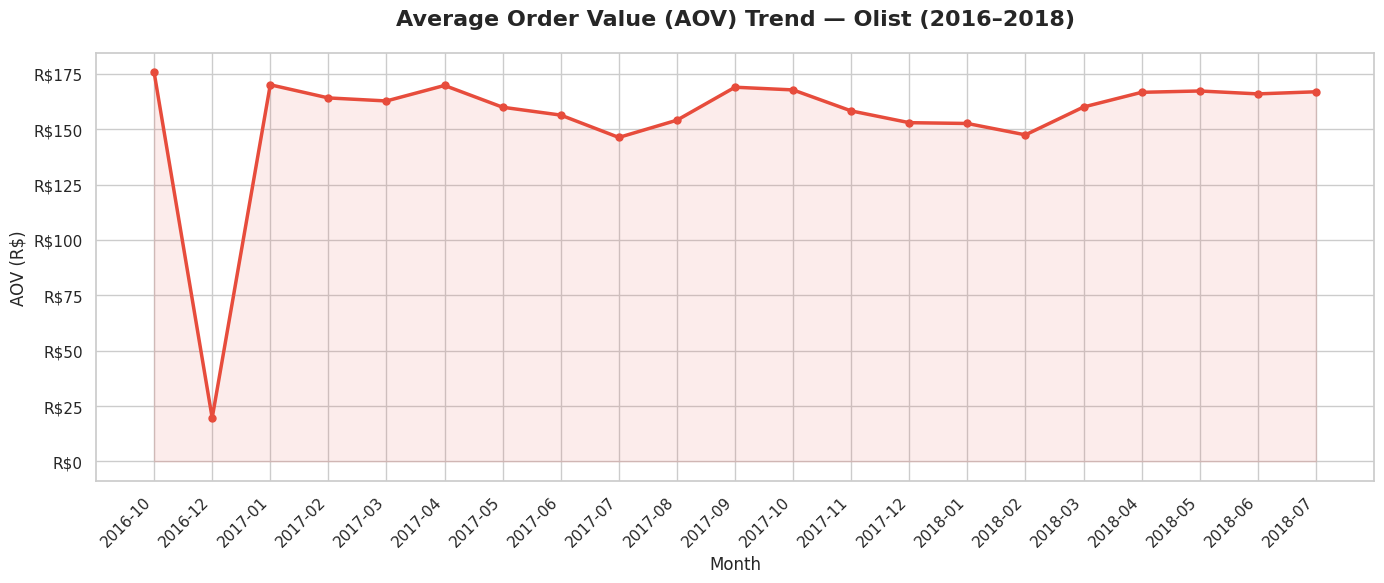

In [45]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_revenue['order_month'].astype(str),
        monthly_revenue['aov'],
        color='#e74c3c', linewidth=2.5, marker='o', markersize=5)

ax.fill_between(monthly_revenue['order_month'].astype(str),
                monthly_revenue['aov'],
                alpha=0.1, color='#e74c3c')

ax.set_title('Average Order Value (AOV) Trend — Olist (2016–2018)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('AOV (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

plt.tight_layout()
plt.savefig('../charts/chart3_aov_trend.png', dpi=150)
plt.show()

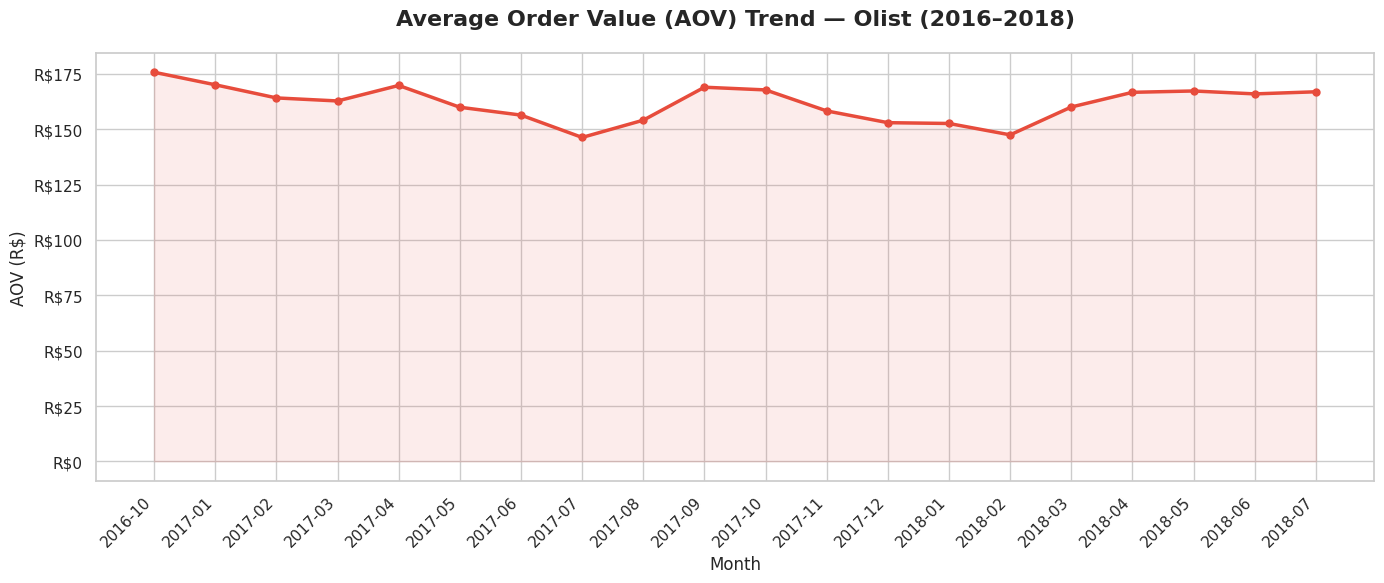

In [46]:
# Removing months with less than 100 orders — not representative
monthly_revenue = monthly_revenue[monthly_revenue['orders'] >= 100]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_revenue['order_month'].astype(str),
        monthly_revenue['aov'],
        color='#e74c3c', linewidth=2.5, marker='o', markersize=5)

ax.fill_between(monthly_revenue['order_month'].astype(str),
                monthly_revenue['aov'],
                alpha=0.1, color='#e74c3c')

ax.set_title('Average Order Value (AOV) Trend — Olist (2016–2018)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('AOV (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

plt.tight_layout()
plt.savefig('../charts/chart3_aov_trend.png', dpi=150)
plt.show()

# Category Analysis

In [47]:
# Category df — item level table for accurate category analysis

In [48]:
category_df = (order_items.merge(products[['product_id','product_category_name']],on = "product_id" ,how = 'left')
                        .merge(category,on="product_category_name",how="left")
                        .merge(delivered_orders[['order_id','order_purchase_timestamp']],on="order_id",how="left")
                        .merge(reviews_agg[['order_id','review_score']],on='order_id',how='left'))

In [49]:
category_df.shape

(112650, 11)

In [50]:
category_df.columns.to_list()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_category_name_english',
 'order_purchase_timestamp',
 'review_score']

In [51]:
# Keep only columns needed for category analysis

In [52]:
category_df=category_df[['order_purchase_timestamp','product_category_name_english','price','review_score']]

In [53]:
category_df.head()

,order_purchase_timestamp,product_category_name_english,price,review_score
0,2017-09-13 08:59:02,cool_stuff,58.90,5.0
1,2017-04-26 10:53:06,pet_shop,239.90,4.0
2,2018-01-14 14:33:31,furniture_decor,199.00,5.0
3,2018-08-08 10:00:35,perfumery,12.99,4.0
4,2017-02-04 13:57:51,garden_tools,199.90,5.0


In [54]:
category_df.shape

(112650, 4)

In [55]:
category_df.isnull().sum()

order_purchase_timestamp         2453
product_category_name_english    1627
price                               0
review_score                      942
dtype: int64

In [56]:
# Drop nulls — timestamp nulls from unmatched orders in left join
# Category nulls — products with no category assigned in source data
category_df = category_df.dropna(subset=['product_category_name_english',
                                          'order_purchase_timestamp'])

In [57]:
category_df.shape

(108638, 4)

In [58]:
category_df.isnull().sum()

order_purchase_timestamp           0
product_category_name_english      0
price                              0
review_score                     815
dtype: int64

In [59]:
#Top 10 Categories by Revenue

In [60]:
category_summary = category_df.groupby('product_category_name_english').agg(
    revenue = ('price','sum'),
    avg_review = ('review_score','mean'),
    item_count = ('price','count')
).reset_index()

In [61]:
category_summary.head()

,product_category_name_english,revenue,avg_review,item_count
0,agro_industry_and_commerce,70566.10,4.087379,206
1,air_conditioning,53323.56,4.052817,289
2,art,23657.30,4.082051,197
3,arts_and_craftmanship,1814.01,4.125000,24
4,audio,50570.60,3.836592,362


In [62]:
top10_products = category_summary.nlargest(10,'revenue')

In [63]:
top10_products[['product_category_name_english', 'revenue', 'avg_review']]

,product_category_name_english,revenue,avg_review
43,health_beauty,1233131.72,4.189729
70,watches_gifts,1166176.98,4.071711
7,bed_bath_table,1023434.76,3.923968
65,sports_leisure,954852.55,4.165493
15,computers_accessories,888724.61,3.986462
39,furniture_decor,711927.69,3.953775
49,housewares,615628.69,4.107904
20,cool_stuff,610204.10,4.194904
5,auto,578966.65,4.116004
69,toys,471286.48,4.208927


## Top 10 categories by revenue

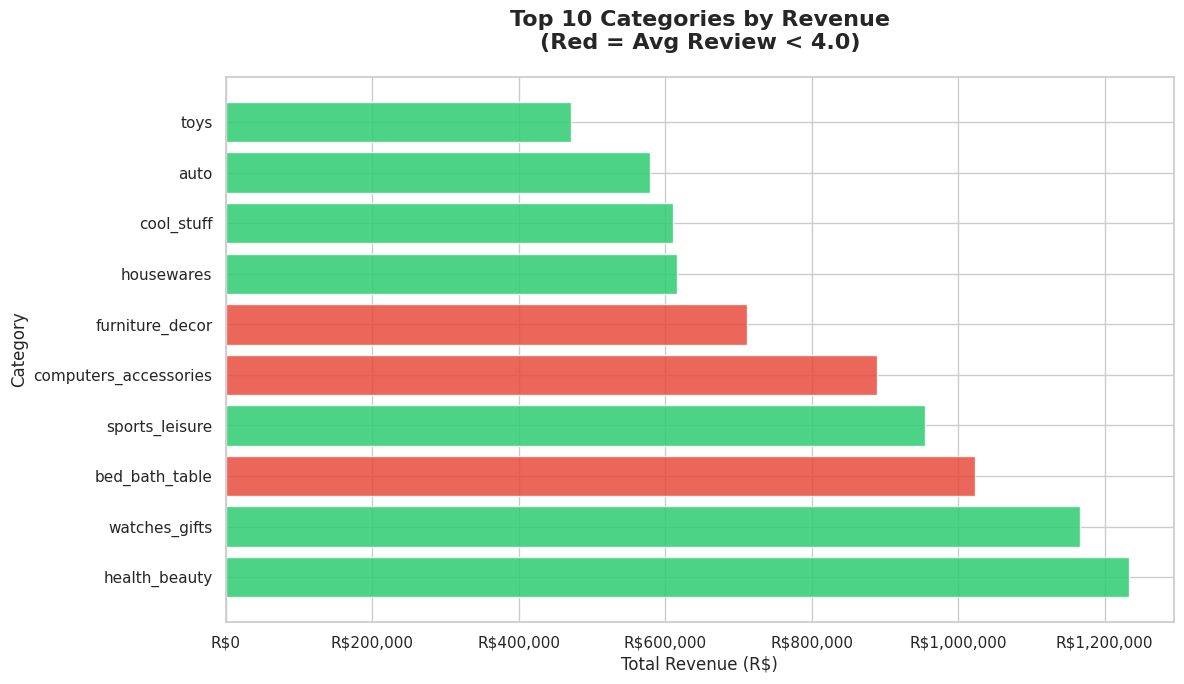

In [64]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#e74c3c' if x < 4.0 else '#2ecc71' 
          for x in top10_products['avg_review']]

ax.barh(top10_products['product_category_name_english'], 
        top10_products['revenue'],
        color=colors, alpha=0.85)

ax.set_title('Top 10 Categories by Revenue\n(Red = Avg Review < 4.0)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Total Revenue (R$)', fontsize=12)
ax.set_ylabel('Category', fontsize=12)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

plt.tight_layout()
plt.savefig('../charts/chart4_top10_categories.png', dpi=150)
plt.show()

In [65]:
# Filtering data with min 100 items 
category_plot = category_summary[category_summary['item_count'] >= 100]

In [66]:
# Calculate medians — used to draw the quadrant lines
median_revenue = category_plot['revenue'].median()
median_review = category_plot['avg_review'].median()

In [67]:
len(category_plot)

53

In [68]:
print(f"Median Revenue: R${median_revenue:,.0f}")
print(f"Median Review Score: {median_review:.2f}")

Median Revenue: R$81,408
Median Review Score: 4.11


## Revenue vs Satisfaction Matrix 

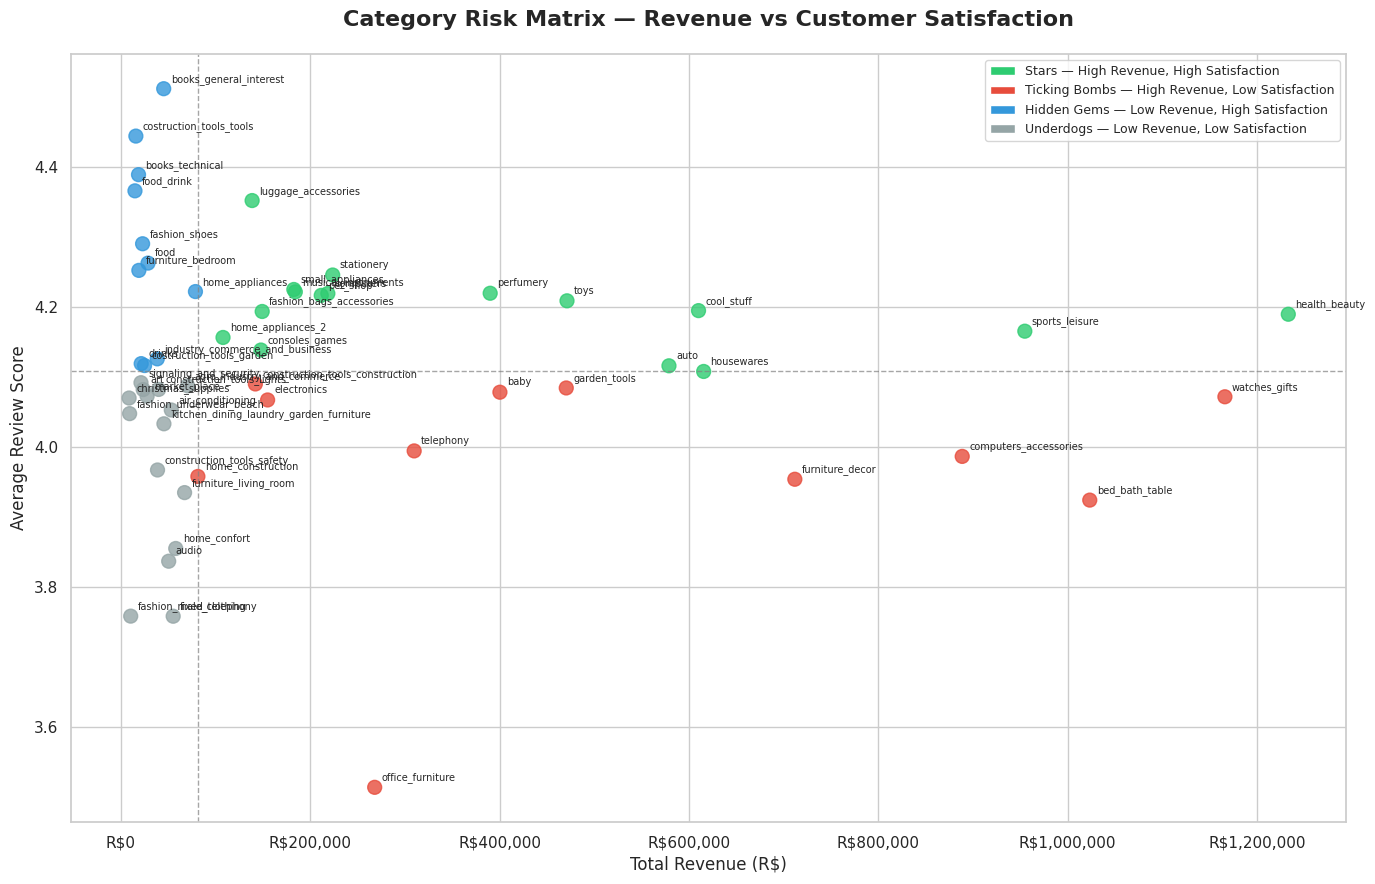

In [69]:
fig, ax = plt.subplots(figsize=(14, 9))

# Draw quadrant lines
ax.axvline(x=median_revenue, color='gray',
           linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=median_review, color='gray',linestyle='--', linewidth=1, alpha=0.7)

# Color points by quadrant
colors = []
labels = []
for _, row in category_plot.iterrows():
    if row['revenue'] >= median_revenue and row['avg_review'] >= median_review:
        colors.append('#2ecc71')
        labels.append('Stars')
    elif row['revenue'] >= median_revenue and row['avg_review'] < median_review:
        colors.append('#e74c3c')
        labels.append('Ticking Bombs')
    elif row['revenue'] < median_revenue and row['avg_review'] >= median_review:
        colors.append('#3498db')
        labels.append('Hidden Gems')
    else:
        colors.append('#95a5a6')
        labels.append('Underdogs')

ax.scatter(category_plot['revenue'],
           category_plot['avg_review'],
           c=colors, s=100, alpha=0.8)

# Label every point
for _, row in category_plot.iterrows():
    ax.annotate(row['product_category_name_english'],
                (row['revenue'], row['avg_review']),
                fontsize=7, ha='left',
                xytext=(5, 5), textcoords='offset points')

# Clean legend instead of quadrant labels
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Stars — High Revenue, High Satisfaction'),
    Patch(facecolor='#e74c3c', label='Ticking Bombs — High Revenue, Low Satisfaction'),
    Patch(facecolor='#3498db', label='Hidden Gems — Low Revenue, High Satisfaction'),
    Patch(facecolor='#95a5a6', label='Underdogs — Low Revenue, Low Satisfaction')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

ax.set_title('Category Risk Matrix — Revenue vs Customer Satisfaction',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Total Revenue (R$)', fontsize=12)
ax.set_ylabel('Average Review Score', fontsize=12)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

plt.tight_layout()
plt.savefig('../charts/chart5_category_matrix.png', dpi=150)
plt.show()

# Delivery Impact on Satisfaction

In [70]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_value,freight_value,...,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_type,payment_installments,review_score,review_comment,product_category_name_english,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,...,3149,sao paulo,SP,38.71,credit_card,1.0,4.0,"Não testei o produto ainda, mas ele veio corre...",housewares,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,...,47813,barreiras,BA,141.46,boleto,1.0,4.0,Muito bom o produto.,perfumery,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,...,75265,vianopolis,GO,179.12,credit_card,3.0,5.0,None,auto,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,...,59296,sao goncalo do amarante,RN,72.20,credit_card,1.0,5.0,O produto foi exatamente o que eu esperava e e...,pet_shop,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,...,9195,santo andre,SP,28.62,credit_card,1.0,5.0,None,stationery,2018-02


In [71]:
# Positive = late, Negative = early
df['delivery_delay'] = (
    df['order_delivered_customer_date'] - 
    df['order_estimated_delivery_date']
).dt.days

print(df['delivery_delay'].describe())

count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay, dtype: float64


In [72]:
# How many orders were delayed more than 30 days?
extreme = df[df['delivery_delay'] > 30]
print(f"Orders delayed 30+ days: {len(extreme):,}")
print(f"Percentage: {len(extreme)/len(df)*100:.2f}%")

Orders delayed 30+ days: 345
Percentage: 0.36%


In [73]:
df['delivery_status'] = df['delivery_delay'].apply(lambda x : "Late" if x>0 else "On-time")

In [74]:
df['delivery_status'].value_counts()

delivery_status
On-time    89944
Late        6534
Name: count, dtype: int64

* Delayed 1+ days  → 6.8%  of orders (6,534 orders)
* Delayed 30+ days → 0.36% of orders (348 orders)

## Review Score Distribution

In [75]:
df['review_score'] = df['review_score'].round()
review_counts = df['review_score'].value_counts().sort_index()
review_counts

review_score
1.0     9313
2.0     2954
3.0     7916
4.0    18945
5.0    56704
Name: count, dtype: int64

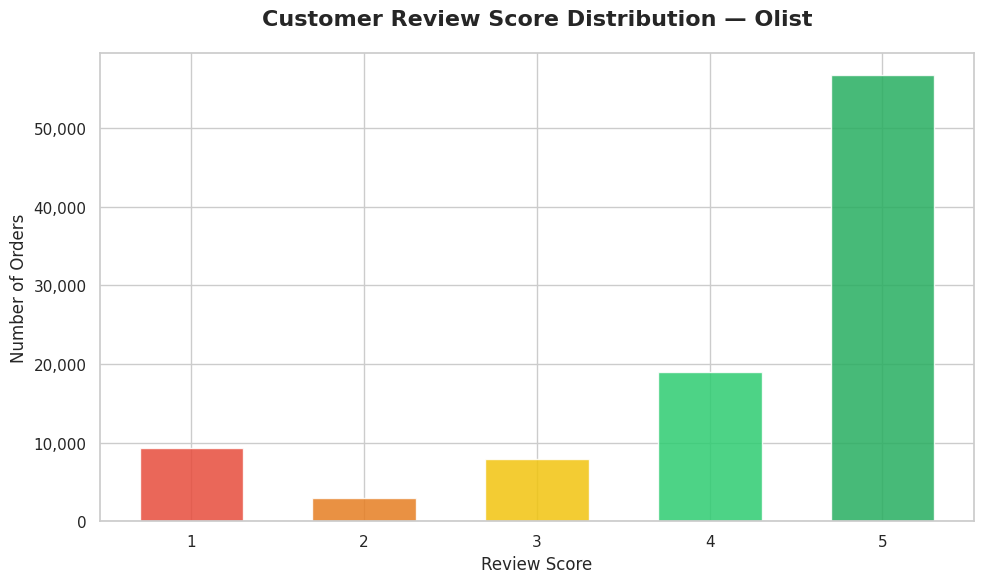

In [76]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#27ae60']

ax.bar(review_counts.index, review_counts.values,
       color=colors, alpha=0.85, edgecolor='white', width=0.6)

ax.set_title('Customer Review Score Distribution — Olist',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Review Score', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.set_xticks([1, 2, 3, 4, 5])
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('../charts/chart6_review_distribution.png', dpi=150)
plt.show()

## Average review score by delivery delay bucket

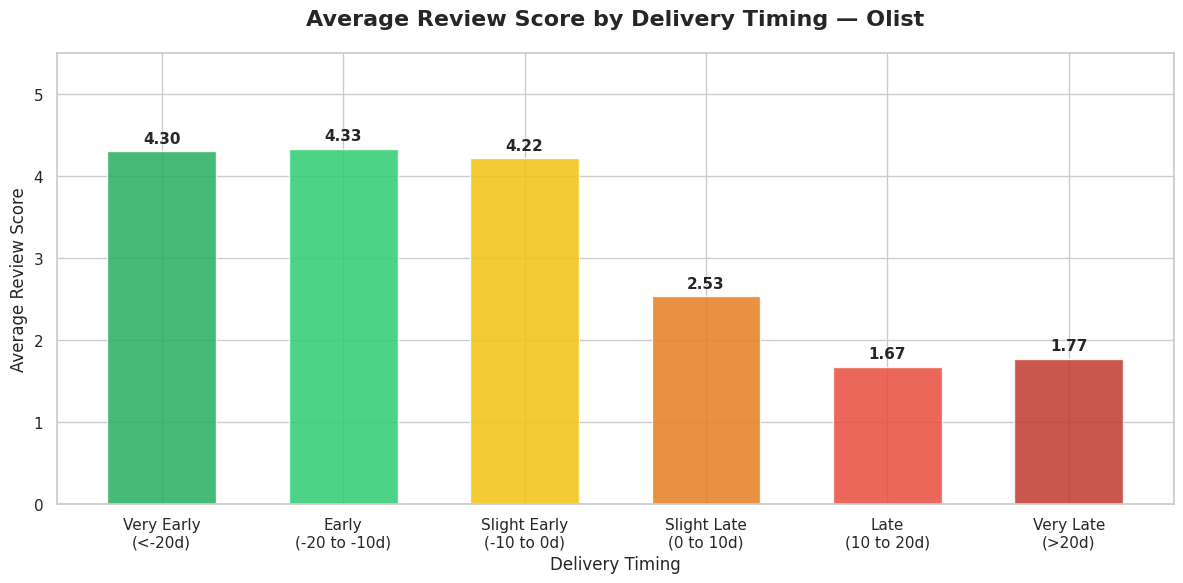

In [77]:
# Create delay buckets for clean visualization
bins = [-150, -20, -10, 0, 10, 20, 200]
labels = ['Very Early\n(<-20d)', 'Early\n(-20 to -10d)', 
          'Slight Early\n(-10 to 0d)', 'Slight Late\n(0 to 10d)', 
          'Late\n(10 to 20d)', 'Very Late\n(>20d)']

df['delay_bucket'] = pd.cut(df['delivery_delay'], 
                             bins=bins, labels=labels)

# Average review per bucket
delay_review = df.groupby('delay_bucket')['review_score'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#27ae60', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b']

ax.bar(delay_review['delay_bucket'],
       delay_review['review_score'],
       color=colors, alpha=0.85, edgecolor='white', width=0.6)

ax.set_title('Average Review Score by Delivery Timing — Olist',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Delivery Timing', fontsize=12)
ax.set_ylabel('Average Review Score', fontsize=12)
ax.set_ylim(0, 5.5)

# Add value labels on bars
for i, row in delay_review.iterrows():
    ax.text(i, row['review_score'] + 0.1, 
            f"{row['review_score']:.2f}",
            ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../charts/chart7_delivery_vs_review.png', dpi=150)
plt.show()

## On-time vs Late delivery satisfaction

In [78]:
ontime_review = df.groupby('delivery_status')['review_score'].mean()

In [79]:
ontime_review

delivery_status
Late       2.271588
On-time    4.290327
Name: review_score, dtype: float64

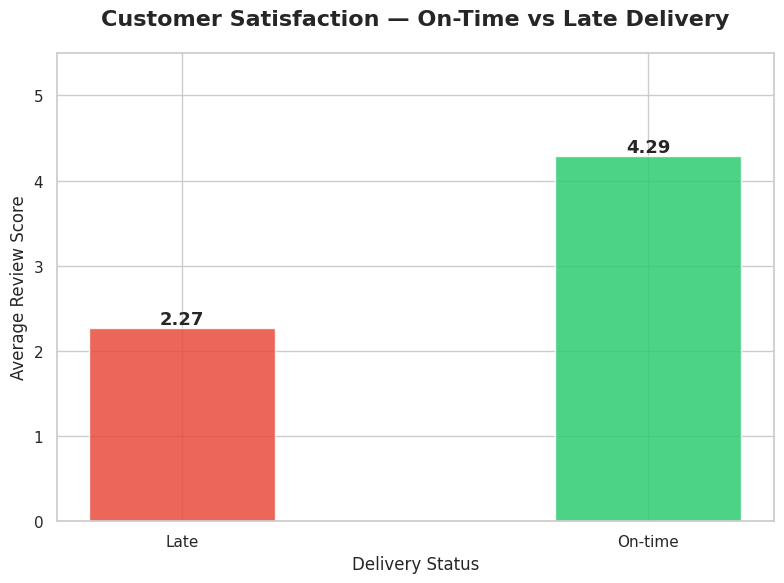

In [80]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#e74c3c','#2ecc71']

ax.bar(ontime_review.index, ontime_review.values,
       color=colors, alpha=0.85, edgecolor='white', width=0.4)

# Add value labels
for i, (status, score) in enumerate(ontime_review.items()):
    ax.text(i, score + 0.05, f'{score:.2f}',
            ha='center', fontsize=13, fontweight='bold')

ax.set_title('Customer Satisfaction — On-Time vs Late Delivery',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Delivery Status', fontsize=12)
ax.set_ylabel('Average Review Score', fontsize=12)
ax.set_ylim(0, 5.5)

plt.tight_layout()
plt.savefig('../charts/chart8_ontime_vs_late.png', dpi=150)
plt.show()

## Revenue and satisfaction by state

In [81]:
state_summary =  df.groupby('customer_state').agg(
    revenue = ('payment_value','sum'),
    orders = ('order_id','count'),
    avg_review = ('review_score','mean')
).reset_index()

In [82]:
state_summary.sort_values('revenue',ascending =False).head(10)

,customer_state,revenue,orders,avg_review
25,SP,5770266.19,40501,4.246369
18,RJ,2055690.45,12350,3.964622
10,MG,1819277.61,11354,4.192291
22,RS,861802.40,5345,4.185283
17,PR,781919.55,4923,4.239388
23,SC,595208.40,3546,4.133276
4,BA,591270.60,3256,3.930009
6,DF,346146.17,2080,4.132850
8,GO,334294.22,1957,4.103803
7,ES,317682.65,1995,4.079228


* SP → 5.77M revenue → 40,501 orders → 4.25 review 
* RJ → 2.05M revenue → 12,350 orders → 3.96 review 
* MG → 1.81M revenue → 11,354 orders → 4.19 review 

## Top 10 States by Revenue

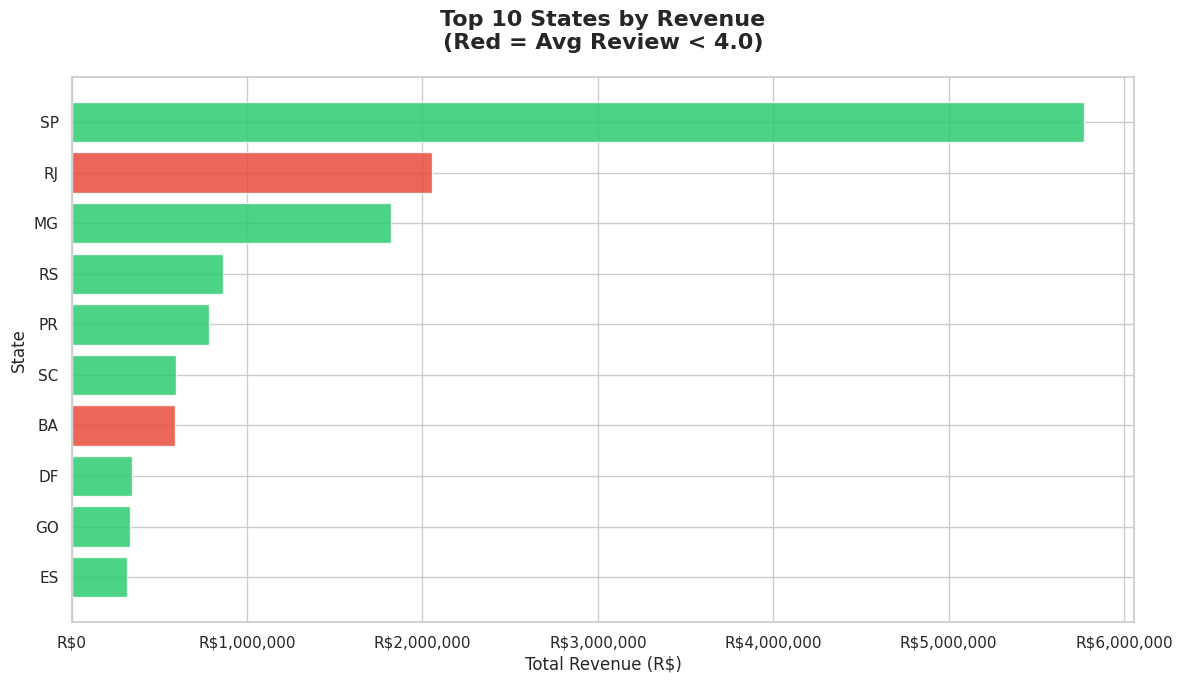

In [83]:
top10_states = state_summary.nlargest(10, 'revenue')

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['#e74c3c' if x < 4.0 else '#2ecc71'
          for x in top10_states['avg_review']]

ax.barh(top10_states['customer_state'],
        top10_states['revenue'],
        color=colors, alpha=0.85)

ax.invert_yaxis()

ax.set_title('Top 10 States by Revenue\n(Red = Avg Review < 4.0)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Total Revenue (R$)', fontsize=12)
ax.set_ylabel('State', fontsize=12)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

plt.tight_layout()
plt.savefig('../charts/chart9_top10_states.png', dpi=150)
plt.show()

## State Opportunity Matrix

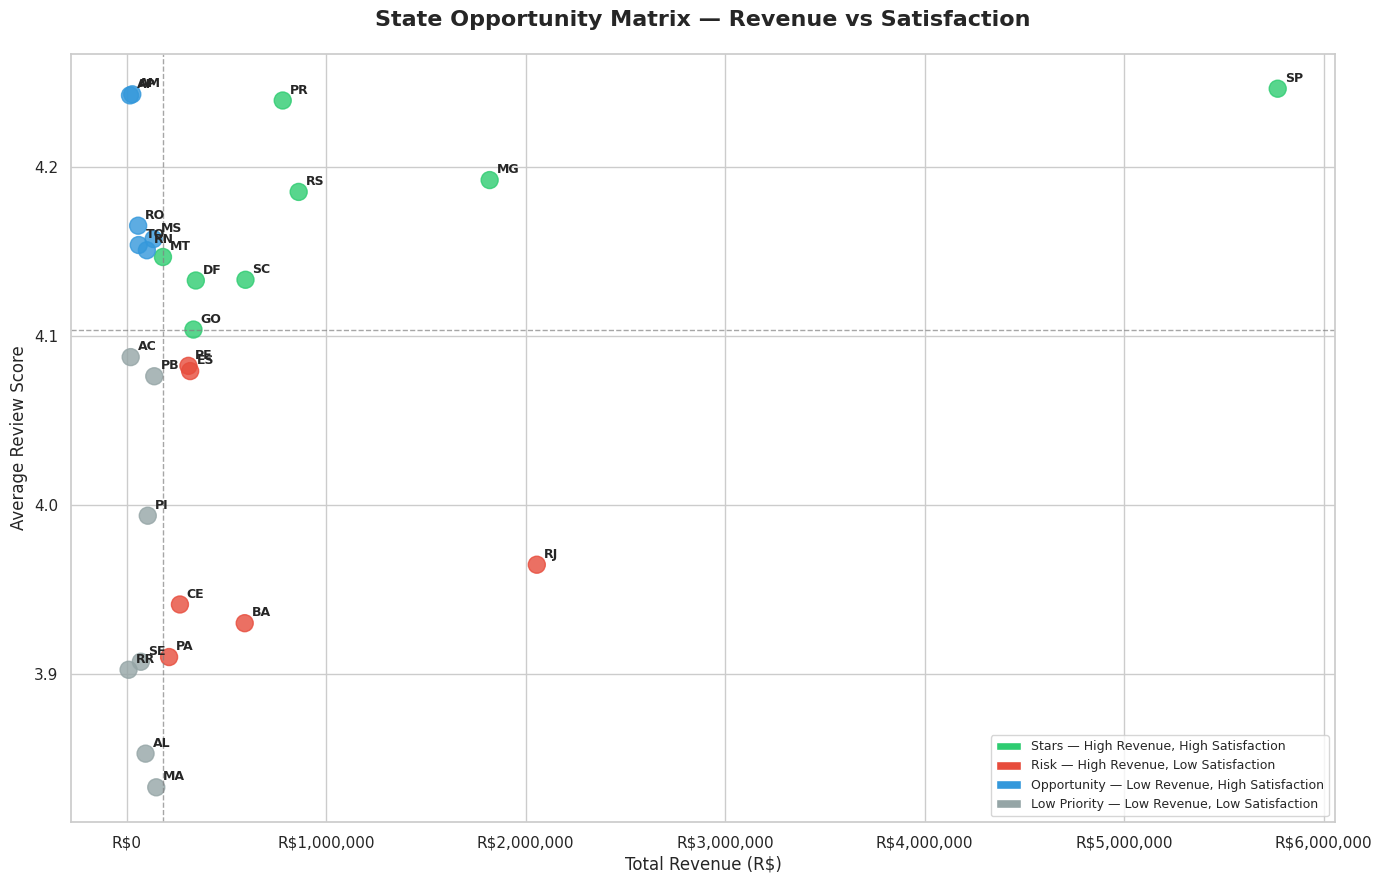

In [87]:
median_state_revenue = state_summary['revenue'].median()
median_state_review = state_summary['avg_review'].median()

fig, ax = plt.subplots(figsize=(14, 9))

# Draw quadrant lines
ax.axvline(x=median_state_revenue, color='gray',
           linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=median_state_review, color='gray',
           linestyle='--', linewidth=1, alpha=0.7)

# Color by quadrant
colors = []
for _, row in state_summary.iterrows():
    if row['revenue'] >= median_state_revenue and row['avg_review'] >= median_state_review:
        colors.append('#2ecc71')
    elif row['revenue'] >= median_state_revenue and row['avg_review'] < median_state_review:
        colors.append('#e74c3c')
    elif row['revenue'] < median_state_revenue and row['avg_review'] >= median_state_review:
        colors.append('#3498db')
    else:
        colors.append('#95a5a6')

ax.scatter(state_summary['revenue'],
           state_summary['avg_review'],
           c=colors, s=150, alpha=0.8)

# Label every state
for _, row in state_summary.iterrows():
    ax.annotate(row['customer_state'],
                (row['revenue'], row['avg_review']),
                fontsize=9, fontweight='bold',
                xytext=(5, 5), textcoords='offset points')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Stars — High Revenue, High Satisfaction'),
    Patch(facecolor='#e74c3c', label='Risk — High Revenue, Low Satisfaction'),
    Patch(facecolor='#3498db', label='Opportunity — Low Revenue, High Satisfaction'),
    Patch(facecolor='#95a5a6', label='Low Priority — Low Revenue, Low Satisfaction')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_title('State Opportunity Matrix — Revenue vs Satisfaction',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Total Revenue (R$)', fontsize=12)
ax.set_ylabel('Average Review Score', fontsize=12)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))

plt.tight_layout()
plt.savefig('../charts/chart10_state_matrix.png', dpi=150)
plt.show()

* STARS (invest more here)
→ SP, MG, RS, PR, SC, GO, DF
→ High revenue + happy customers
→ Olist's strongest markets

* RISK (fix urgently)
→ RJ, BA, ES, PE
→ High revenue BUT unhappy customers
→ Revenue at risk if satisfaction drops further

* OPPORTUNITY (grow here)
→ MS, MT, RO and others
→ Low revenue BUT happy customers
→ Untapped markets with good potential

* LOW PRIORITY
→ AL, MA, PI, AC, RR, SE
→ Low revenue + unhappy customers
→ Don't invest here yet